<a href="https://colab.research.google.com/github/munozfloresnelsont12-oss/PPIA-github/blob/main/Arbol_de_decision.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# Carga y Preparación del Dataset

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
# 1. Descargar y cargar el dataset desde el enlace
url = "https://raw.githubusercontent.com/kb22/Heart-Disease-Prediction/refs/heads/master/dataset.csv"
df = pd.read_csv(url)

# 2. Verificar las dimensiones del DataFrame
print("--- Dimensiones del Dataset ---")
print(f"Filas: {df.shape[0]} | Columnas: {df.shape[1]}")
print("\n" + "="*50 + "\n")

# 3. Verificar los tipos de datos de las columnas
print("--- Tipos de Datos (.info()) ---")
df.info()

--- Dimensiones del Dataset ---
Filas: 303 | Columnas: 14


--- Tipos de Datos (.info()) ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       303 non-null    int64  
 1   sex       303 non-null    int64  
 2   cp        303 non-null    int64  
 3   trestbps  303 non-null    int64  
 4   chol      303 non-null    int64  
 5   fbs       303 non-null    int64  
 6   restecg   303 non-null    int64  
 7   thalach   303 non-null    int64  
 8   exang     303 non-null    int64  
 9   oldpeak   303 non-null    float64
 10  slope     303 non-null    int64  
 11  ca        303 non-null    int64  
 12  thal      303 non-null    int64  
 13  target    303 non-null    int64  
dtypes: float64(1), int64(13)
memory usage: 33.3 KB


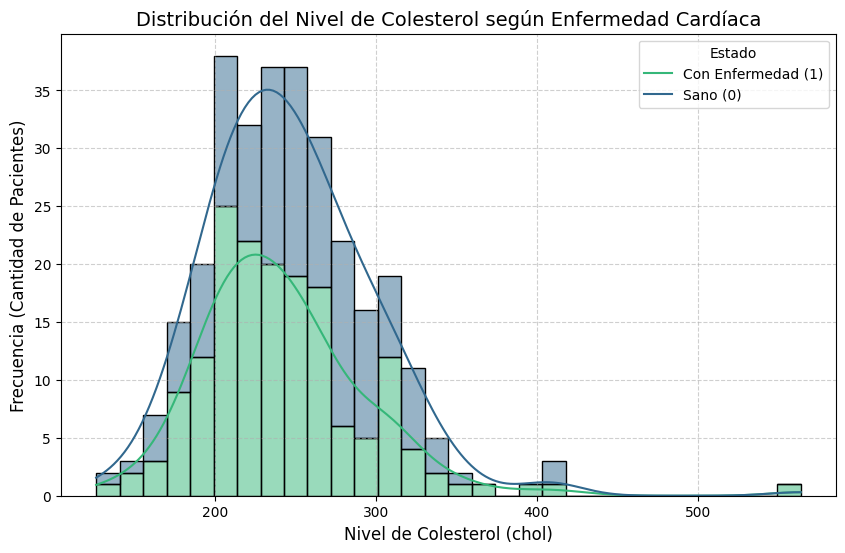

In [ ]:
# Análisis Exploratorio de Datos (EDA)

# Configurar el estilo del gráfico
plt.figure(figsize=(10, 6))

# Generar el histograma segmentado por la presencia de enfermedad cardíaca (columna 'target')
sns.histplot(data=df, x='chol', hue='target', multiple='stack', kde=True, palette='viridis', bins=30)

# Añadir títulos y etiquetas
plt.title('Distribución del Nivel de Colesterol según Enfermedad Cardíaca', fontsize=14)
plt.xlabel('Nivel de Colesterol (chol)', fontsize=12)
plt.ylabel('Frecuencia (Cantidad de Pacientes)', fontsize=12)

# Ajustar la leyenda para que sea más clara (0 = Sano, 1 = Con enfermedad)
plt.legend(title='Estado', labels=['Con Enfermedad (1)', 'Sano (0)'])

plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

In [ ]:
# División y Escalado de Datos

from sklearn.model_selection import train_test_split

# 1. Dividir los datos en atributos (X) y etiquetas (y)
# 'target' es la columna que queremos predecir
X = df.drop(columns=['target'])
y = df['target']

# 2. Realizar la partición de entrenamiento (80%) y prueba (20%)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# 3. Verificación de las dimensiones
print("Datos divididos correctamente.")
print(f"Muestras de entrenamiento (X_train): {X_train.shape[0]}")
print(f"Muestras de prueba (X_test): {X_test.shape[0]}")

Datos divididos correctamente.
Muestras de entrenamiento (X_train): 242
Muestras de prueba (X_test): 61


In [ ]:
# Entrenamiento del Modelo

from sklearn.tree import DecisionTreeClassifier

# 1. Inicializar el modelo con max_depth=3
clf_tree = DecisionTreeClassifier(max_depth=3, random_state=42)

# 2. Entrenar el modelo con los datos de entrenamiento
clf_tree.fit(X_train, y_train)

print("¡Modelo de Árbol de Decisión entrenado con éxito con max_depth=3!")

¡Modelo de Árbol de Decisión entrenado con éxito con max_depth=3!


--- Predicciones de muestra (3 ejemplos) ---
Ejemplo 1: Valor Real = Sano | Predicción del Modelo = Sano
Ejemplo 2: Valor Real = Sano | Predicción del Modelo = Con Enfermedad
Ejemplo 3: Valor Real = Con Enfermedad | Predicción del Modelo = Con Enfermedad


--- Reporte de Clasificación ---
                    precision    recall  f1-score   support

          Sano (0)       0.80      0.83      0.81        29
Con Enfermedad (1)       0.84      0.81      0.83        32

          accuracy                           0.82        61
         macro avg       0.82      0.82      0.82        61
      weighted avg       0.82      0.82      0.82        61



--- Matriz de Confusión ---


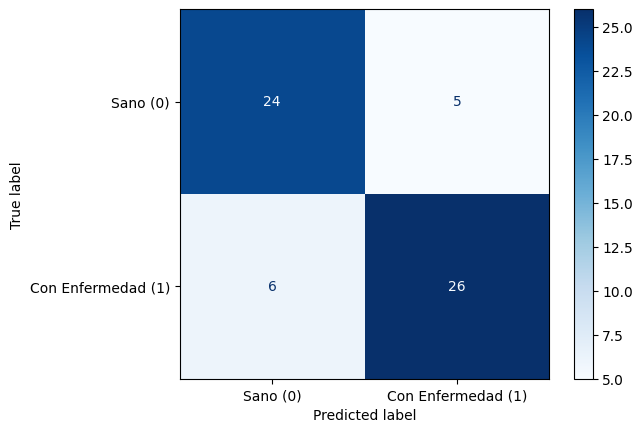

In [ ]:
# Evaluación del Modelo
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report

# 1. Realizar 3 predicciones con tres ejemplos del conjunto de prueba
X_sample = X_test[:3]
y_sample_true = y_test[:3].values

predictions_sample = clf_tree.predict(X_sample)

print("--- Predicciones de muestra (3 ejemplos) ---")
for i in range(3):
    estado_real = "Con Enfermedad" if y_sample_true[i] == 1 else "Sano"
    estado_pred = "Con Enfermedad" if predictions_sample[i] == 1 else "Sano"
    print(f"Ejemplo {i+1}: Valor Real = {estado_real} | Predicción del Modelo = {estado_pred}")
print("\n" + "="*50 + "\n")

# 2. Predecir para todo el conjunto de prueba
y_pred_all = clf_tree.predict(X_test)

# 3. Calcular e imprimir el reporte de clasificación
print("--- Reporte de Clasificación ---")
print(classification_report(y_test, y_pred_all, target_names=['Sano (0)', 'Con Enfermedad (1)']))
print("\n" + "="*50 + "\n")

# 4. Calcular y mostrar la Matriz de Confusión de forma gráfica
cm = confusion_matrix(y_test, y_pred_all)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Sano (0)', 'Con Enfermedad (1)'])

print("--- Matriz de Confusión ---")
disp.plot(cmap='Blues')
plt.show()

En esta actividad se construyó un modelo de clasificación utilizando un Árbol de Decisión para predecir la presencia de enfermedades cardíacas a partir del dataset de la UCI.
Configurar el hiperparámetro max_depth=3 fue clave para limitar el crecimiento del árbol, asegurando un modelo visualmente interpretable y protegido contra el sobreajuste.
A diferencia de la regresión, aquí evaluamos el éxito mediante la Matriz de Confusión y el Reporte de Clasificación, herramientas que permitieron analizar al detalle la precisión del modelo tanto para identificar pacientes sanos como enfermos.
